In [ ]:
!pip install -q neuprint-python networkx joblib

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from scipy.spatial import cKDTree
from scipy.stats import spearmanr, pearsonr

from neuprint import (
    Client,
    fetch_synapse_connections,
    fetch_adjacencies,
    fetch_skeleton,
    NeuronCriteria as NC
)

from neuprint.skeleton import skeleton_df_to_nx, upsample_skeleton

from google.colab import userdata

In [ ]:
# =========================
# CONFIG
# =========================

DATASET = "hemibrain:v1.2.1"
SERVER = "neuprint.janelia.org"

# Hemibrain coordinates are in raw voxel-like units.
# We keep the same conversion used in the previous notebook.
VOXEL_NM = 8

NUM_HUBS_TEST = 5
WEIGHT_THRESHOLD = 5

# Start tiny. We only sanity-check one hub first.
TEST_HUB_INDEX = 0

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
auth_token = userdata.get("NEUPRINT_TOKEN")

np_client = Client(
    SERVER,
    dataset=DATASET,
    token=auth_token
)

print("Connected to NeuPrint:", DATASET)

Connected to NeuPrint: hemibrain:v1.2.1


In [ ]:
def fetch_top_hubs(num_hubs=5):
    query = f"""
    MATCH (pre:Neuron)-[:ConnectsTo]->(post:Neuron {{status: 'Traced', cropped: false}})
    RETURN post.bodyId AS bodyId,
           count(DISTINCT pre.bodyId) AS unique_in_degree
    ORDER BY unique_in_degree DESC
    LIMIT {num_hubs}
    """
    hubs_df = np_client.fetch_custom(query)
    hubs_df["bodyId"] = hubs_df["bodyId"].astype(int)
    return hubs_df

hubs_df = fetch_top_hubs(NUM_HUBS_TEST)

display(hubs_df)

TEST_HUB = int(hubs_df.iloc[TEST_HUB_INDEX]["bodyId"])
print("Test hub:", TEST_HUB)

,bodyId,unique_in_degree
0,2124762952,4388
1,425790257,3146
2,329566174,3119
3,1640909284,3020
4,425276848,2997


Test hub: 2124762952


In [ ]:
# Fetch all synapse-level connections into the hub
syn_conn = fetch_synapse_connections(None, TEST_HUB)

# Keep only connections where the hub is the postsynaptic neuron
hub_syn = syn_conn[syn_conn["bodyId_post"] == TEST_HUB].copy()

print("Raw columns:")
print(hub_syn.columns.tolist())

required_cols = [
    "bodyId_pre",
    "bodyId_post",
    "x_post",
    "y_post",
    "z_post"
]

missing = [c for c in required_cols if c not in hub_syn.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

# Rename post coordinates to generic x/y/z because these are the coordinates on the hub
hub_syn = hub_syn[required_cols].dropna().copy()
hub_syn = hub_syn.rename(
    columns={
        "x_post": "x",
        "y_post": "y",
        "z_post": "z"
    }
)

hub_syn["bodyId_pre"] = hub_syn["bodyId_pre"].astype(int)
hub_syn["bodyId_post"] = hub_syn["bodyId_post"].astype(int)

print(f"Hub: {TEST_HUB}")
print(f"Synapses onto hub: {len(hub_syn):,}")
print(f"Unique presynaptic neurons: {hub_syn['bodyId_pre'].nunique():,}")

display(hub_syn.head())

top_inputs = (
    hub_syn
    .groupby("bodyId_pre")
    .size()
    .reset_index(name="synapses_onto_hub")
    .sort_values("synapses_onto_hub", ascending=False)
)

display(top_inputs.head(10))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/19584 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Raw columns:
['bodyId_pre', 'bodyId_post', 'roi_pre', 'roi_post', 'x_pre', 'y_pre', 'z_pre', 'x_post', 'y_post', 'z_post', 'confidence_pre', 'confidence_post']
Hub: 2124762952
Synapses onto hub: 19,584
Unique presynaptic neurons: 4,388


,bodyId_pre,bodyId_post,x,y,z
0,2432422826,2124762952,10901,16354,35295
1,2432422826,2124762952,10501,15867,34952
2,2432422826,2124762952,10540,15778,34877
3,2432422826,2124762952,11023,17028,35677
4,2432422826,2124762952,10688,15453,34655


,bodyId_pre,synapses_onto_hub
4281,5813061218,793
324,1343403608,268
4280,5813061112,255
50,912601209,211
16,697882667,140
4271,5813055495,58
885,1562004333,53
1731,1843714565,51
37,852738570,49
1296,1692627340,47


In [ ]:
# Fetch the skeleton of the hub itself
skel = fetch_skeleton(TEST_HUB, heal=True)

print("Skeleton columns:")
print(skel.columns.tolist())

display(skel.head())

required_skel_cols = ["rowId", "x", "y", "z", "link"]
missing = [c for c in required_skel_cols if c not in skel.columns]
assert len(missing) == 0, f"Missing skeleton columns: {missing}"

print(f"Skeleton nodes: {len(skel):,}")
print(f"Number of roots / fragments after heal=True: {(skel['link'] == -1).sum()}")

Skeleton columns:
['rowId', 'x', 'y', 'z', 'radius', 'link']


,rowId,x,y,z,radius,link
0,1,2688.0,14896.0,18012.0,14.000000,-1
1,2,2716.0,14924.0,18040.0,25.598000,1
2,3,2744.0,14952.0,18012.0,42.000000,2
3,4,2856.0,15064.0,18096.0,86.955399,3
4,5,2940.0,15120.0,18208.0,48.609901,4


Skeleton nodes: 75,119
Number of roots / fragments after heal=True: 1


In [ ]:
# Convert skeleton dataframe to a NetworkX graph.
# directed=False because geodesic distance along the morphology should be symmetric.
G = skeleton_df_to_nx(
    skel,
    directed=False,
    with_distances=True
)

# Convert edge distance from raw coordinate units to nm
for u, v, data in G.edges(data=True):
    data["distance_nm"] = data["distance"] * VOXEL_NM

print("Graph sanity check")
print("------------------")
print(f"Nodes: {G.number_of_nodes():,}")
print(f"Edges: {G.number_of_edges():,}")
print(f"Connected components: {nx.number_connected_components(G)}")

component_sizes = sorted(
    [len(c) for c in nx.connected_components(G)],
    reverse=True
)

print("Largest component sizes:", component_sizes[:5])

Graph sanity check
------------------
Nodes: 75,119
Edges: 75,118
Connected components: 1
Largest component sizes: [75119]


In [ ]:
# Reset index so KDTree index lines up cleanly with dataframe rows
skel_nodes = skel[["rowId", "x", "y", "z"]].copy().reset_index(drop=True)

skel_tree = cKDTree(skel_nodes[["x", "y", "z"]].values)

syn_coords = hub_syn[["x", "y", "z"]].values

nearest_dist_raw, nearest_idx = skel_tree.query(syn_coords, k=1)

hub_syn_mapped = hub_syn.copy()
hub_syn_mapped["nearest_skel_rowId"] = skel_nodes.iloc[nearest_idx]["rowId"].values
hub_syn_mapped["dist_to_skeleton_nm"] = nearest_dist_raw * VOXEL_NM

print("Synapse-to-skeleton mapping sanity check")
print("----------------------------------------")
print(f"Mapped synapses: {len(hub_syn_mapped):,}")
print(f"Median snap distance to skeleton: {hub_syn_mapped['dist_to_skeleton_nm'].median():,.1f} nm")
print(f"95th percentile snap distance: {hub_syn_mapped['dist_to_skeleton_nm'].quantile(0.95):,.1f} nm")
print(f"Max snap distance: {hub_syn_mapped['dist_to_skeleton_nm'].max():,.1f} nm")

display(hub_syn_mapped.head())

snap_summary = hub_syn_mapped["dist_to_skeleton_nm"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
display(snap_summary)

Synapse-to-skeleton mapping sanity check
----------------------------------------
Mapped synapses: 19,584
Median snap distance to skeleton: 276.0 nm
95th percentile snap distance: 810.3 nm
Max snap distance: 1,848.6 nm


,bodyId_pre,bodyId_post,x,y,z,nearest_skel_rowId,dist_to_skeleton_nm
0,2432422826,2124762952,10901,16354,35295,54679,253.450637
1,2432422826,2124762952,10501,15867,34952,54780,152.210381
2,2432422826,2124762952,10540,15778,34877,54791,356.785650
3,2432422826,2124762952,11023,17028,35677,54872,405.561339
4,2432422826,2124762952,10688,15453,34655,54751,211.357517


,dist_to_skeleton_nm
count,19584.000000
mean,344.343769
std,226.977868
min,11.313708
50%,275.971013
90%,667.221103
95%,810.321417
99%,1106.826708
max,1848.619328


In [ ]:
# Pick two input neurons with many synapses onto the hub
top_two_neurons = top_inputs.head(2)["bodyId_pre"].astype(int).tolist()

n1, n2 = top_two_neurons

print("Testing geodesic distance between:")
print("Neuron 1:", n1)
print("Neuron 2:", n2)

syn1 = hub_syn_mapped[hub_syn_mapped["bodyId_pre"] == n1].copy()
syn2 = hub_syn_mapped[hub_syn_mapped["bodyId_pre"] == n2].copy()

nodes1 = syn1["nearest_skel_rowId"].astype(int).unique().tolist()
nodes2 = syn2["nearest_skel_rowId"].astype(int).unique().tolist()

print(f"Neuron 1 synapses onto hub: {len(syn1):,}")
print(f"Neuron 2 synapses onto hub: {len(syn2):,}")
print(f"Neuron 1 unique skeleton nodes: {len(nodes1):,}")
print(f"Neuron 2 unique skeleton nodes: {len(nodes2):,}")

# Multi-source Dijkstra:
# distance from every node in nodes1 to the nearest source node in nodes2
dist_to_n2 = nx.multi_source_dijkstra_path_length(
    G,
    sources=nodes2,
    weight="distance_nm"
)

# distance from every node in nodes2 to the nearest source node in nodes1
dist_to_n1 = nx.multi_source_dijkstra_path_length(
    G,
    sources=nodes1,
    weight="distance_nm"
)

n1_to_n2 = np.array([dist_to_n2[node] for node in nodes1 if node in dist_to_n2])
n2_to_n1 = np.array([dist_to_n1[node] for node in nodes2 if node in dist_to_n1])

all_nearest = np.concatenate([n1_to_n2, n2_to_n1])

print()
print("Geodesic distance sanity check")
print("------------------------------")
print(f"Minimum geodesic distance: {all_nearest.min():,.1f} nm")
print(f"Mean nearest-neighbor geodesic distance: {all_nearest.mean():,.1f} nm")
print(f"Median nearest-neighbor geodesic distance: {np.median(all_nearest):,.1f} nm")
print(f"10th percentile geodesic distance: {np.percentile(all_nearest, 10):,.1f} nm")

Testing geodesic distance between:
Neuron 1: 5813061218
Neuron 2: 1343403608
Neuron 1 synapses onto hub: 793
Neuron 2 synapses onto hub: 268
Neuron 1 unique skeleton nodes: 661
Neuron 2 unique skeleton nodes: 261

Geodesic distance sanity check
------------------------------
Minimum geodesic distance: 0.0 nm
Mean nearest-neighbor geodesic distance: 20,965.2 nm
Median nearest-neighbor geodesic distance: 14,615.7 nm
10th percentile geodesic distance: 1,134.4 nm


In [ ]:
coords1 = syn1[["x", "y", "z"]].values
coords2 = syn2[["x", "y", "z"]].values

tree2 = cKDTree(coords2)
euc_dists_raw, _ = tree2.query(coords1, k=1)

euclidean_min_nm = euc_dists_raw.min() * VOXEL_NM
euclidean_mean_nn_nm = euc_dists_raw.mean() * VOXEL_NM

comparison = pd.DataFrame([
    {
        "metric": "Euclidean min distance",
        "distance_nm": euclidean_min_nm
    },
    {
        "metric": "Euclidean mean nearest-neighbor distance",
        "distance_nm": euclidean_mean_nn_nm
    },
    {
        "metric": "Geodesic min distance",
        "distance_nm": all_nearest.min()
    },
    {
        "metric": "Geodesic mean nearest-neighbor distance",
        "distance_nm": all_nearest.mean()
    },
    {
        "metric": "Geodesic 10th percentile distance",
        "distance_nm": np.percentile(all_nearest, 10)
    }
])

display(comparison)

,metric,distance_nm
0,Euclidean min distance,166.469216
1,Euclidean mean nearest-neighbor distance,5219.179113
2,Geodesic min distance,0.000000
3,Geodesic mean nearest-neighbor distance,20965.249694
4,Geodesic 10th percentile distance,1134.446930


In [ ]:
# Check whether the two neurons share nearest skeleton nodes

shared_nodes = set(nodes1).intersection(set(nodes2))

print(f"Shared skeleton nodes between neuron {n1} and neuron {n2}: {len(shared_nodes)}")

if len(shared_nodes) > 0:
    shared_nodes_list = list(shared_nodes)[:10]
    print("Example shared skeleton nodes:", shared_nodes_list)

    shared_syn1 = syn1[syn1["nearest_skel_rowId"].isin(shared_nodes)]
    shared_syn2 = syn2[syn2["nearest_skel_rowId"].isin(shared_nodes)]

    print()
    print(f"Neuron 1 synapses mapped to shared nodes: {len(shared_syn1)}")
    print(f"Neuron 2 synapses mapped to shared nodes: {len(shared_syn2)}")

    display(shared_syn1.head())
    display(shared_syn2.head())
else:
    print("No shared skeleton nodes, so the zero may come from duplicate/edge-case path handling.")

Shared skeleton nodes between neuron 5813061218 and neuron 1343403608: 6
Example shared skeleton nodes: [16768, 27176, 17800, 71409, 45721, 60251]

Neuron 1 synapses mapped to shared nodes: 8
Neuron 2 synapses mapped to shared nodes: 6


,bodyId_pre,bodyId_post,x,y,z,nearest_skel_rowId,dist_to_skeleton_nm
17063,5813061218,2124762952,1330,18957,25861,71409,267.492056
17173,5813061218,2124762952,1335,15981,20043,17800,896.678315
17194,5813061218,2124762952,1339,15904,20070,17800,363.890093
17233,5813061218,2124762952,5760,12359,28848,60251,494.772675
17276,5813061218,2124762952,328,17443,24237,16768,466.064373


,bodyId_pre,bodyId_post,x,y,z,nearest_skel_rowId,dist_to_skeleton_nm
14542,1343403608,2124762952,7096,19113,33697,45721,384.166631
14549,1343403608,2124762952,5658,12330,28849,60251,439.417797
14566,1343403608,2124762952,1394,15947,20093,17800,664.240920
14572,1343403608,2124762952,2266,17360,29900,27176,652.085884
14578,1343403608,2124762952,1323,18915,25866,71409,162.775920


In [ ]:
pair_snap_summary = pd.DataFrame([
    {
        "neuron": n1,
        "synapses": len(syn1),
        "median_snap_nm": syn1["dist_to_skeleton_nm"].median(),
        "p90_snap_nm": syn1["dist_to_skeleton_nm"].quantile(0.90),
        "p95_snap_nm": syn1["dist_to_skeleton_nm"].quantile(0.95),
        "max_snap_nm": syn1["dist_to_skeleton_nm"].max(),
    },
    {
        "neuron": n2,
        "synapses": len(syn2),
        "median_snap_nm": syn2["dist_to_skeleton_nm"].median(),
        "p90_snap_nm": syn2["dist_to_skeleton_nm"].quantile(0.90),
        "p95_snap_nm": syn2["dist_to_skeleton_nm"].quantile(0.95),
        "max_snap_nm": syn2["dist_to_skeleton_nm"].max(),
    }
])

display(pair_snap_summary)

,neuron,synapses,median_snap_nm,p90_snap_nm,p95_snap_nm,max_snap_nm
0,5813061218,793,286.775173,614.168550,695.418873,1313.998478
1,1343403608,268,246.510971,538.694102,689.084649,1198.479036


,0
count,922.000000
mean,20965.249694
std,22806.900334
min,0.000000
1%,0.000000
5%,672.000000
10%,1134.446930
25%,4027.646942
50%,14615.706635
75%,27518.246622


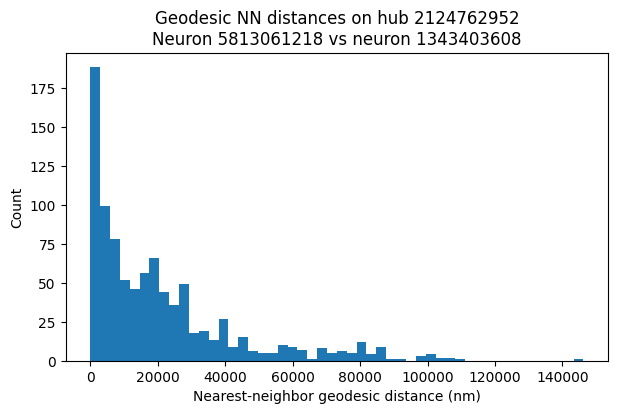

In [ ]:
geo_summary = pd.Series(all_nearest).describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

display(geo_summary)

plt.figure(figsize=(7, 4))
plt.hist(all_nearest, bins=50)
plt.xlabel("Nearest-neighbor geodesic distance (nm)")
plt.ylabel("Count")
plt.title(f"Geodesic NN distances on hub {TEST_HUB}\nNeuron {n1} vs neuron {n2}")
plt.show()

In [ ]:
# Symmetric Euclidean nearest-neighbor distances
tree1 = cKDTree(coords1)
tree2 = cKDTree(coords2)

euc_1_to_2_raw, _ = tree2.query(coords1, k=1)
euc_2_to_1_raw, _ = tree1.query(coords2, k=1)

euc_all_nearest = np.concatenate([euc_1_to_2_raw, euc_2_to_1_raw]) * VOXEL_NM

comparison_summary = pd.DataFrame({
    "euclidean_nn_nm": pd.Series(euc_all_nearest).describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "geodesic_nn_nm": pd.Series(all_nearest).describe(
        percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
})

display(comparison_summary)

ratio_summary = pd.DataFrame([
    {
        "metric": "min",
        "euclidean_nm": np.min(euc_all_nearest),
        "geodesic_nm": np.min(all_nearest),
        "geo_over_euc": np.min(all_nearest) / np.min(euc_all_nearest) if np.min(euc_all_nearest) > 0 else np.nan
    },
    {
        "metric": "p10",
        "euclidean_nm": np.percentile(euc_all_nearest, 10),
        "geodesic_nm": np.percentile(all_nearest, 10),
        "geo_over_euc": np.percentile(all_nearest, 10) / np.percentile(euc_all_nearest, 10)
    },
    {
        "metric": "median",
        "euclidean_nm": np.median(euc_all_nearest),
        "geodesic_nm": np.median(all_nearest),
        "geo_over_euc": np.median(all_nearest) / np.median(euc_all_nearest)
    },
    {
        "metric": "mean",
        "euclidean_nm": np.mean(euc_all_nearest),
        "geodesic_nm": np.mean(all_nearest),
        "geo_over_euc": np.mean(all_nearest) / np.mean(euc_all_nearest)
    }
])

display(ratio_summary)

,euclidean_nn_nm,geodesic_nn_nm
count,1061.000000,922.000000
mean,5200.742541,20965.249694
std,3474.357434,22806.900334
min,166.469216,0.000000
1%,342.975218,0.000000
5%,773.894050,672.000000
10%,1093.573957,1134.446930
25%,2177.837459,4027.646942
50%,4978.758078,14615.706635
75%,7447.514485,27518.246622


,metric,euclidean_nm,geodesic_nm,geo_over_euc
0,min,166.469216,0.000000,0.000000
1,p10,1093.573957,1134.446930,1.037376
2,median,4978.758078,14615.706635,2.935613
3,mean,5200.742541,20965.249694,4.031203


In [ ]:
from joblib import Parallel, delayed
import time

def clean_directed_edges(edges_df, weight_threshold=5):
    """
    Keep directed neuron-neuron edges.

    Each row is:
        source_neuron -> target_neuron

    Weight = total synapse count from source to target,
    aggregated across ROIs if fetch_adjacencies returns ROI-level rows.
    """
    if edges_df is None or edges_df.empty:
        return pd.DataFrame(
            columns=["source_neuron", "target_neuron", "directed_weight"]
        )

    df = edges_df.copy()

    directed_df = (
        df.groupby(["bodyId_pre", "bodyId_post"], as_index=False)["weight"]
        .sum()
        .rename(
            columns={
                "bodyId_pre": "source_neuron",
                "bodyId_post": "target_neuron",
                "weight": "directed_weight"
            }
        )
    )

    directed_df["source_neuron"] = directed_df["source_neuron"].astype(int)
    directed_df["target_neuron"] = directed_df["target_neuron"].astype(int)

    directed_df = directed_df[
        directed_df["source_neuron"] != directed_df["target_neuron"]
    ].copy()

    directed_df = directed_df[
        directed_df["directed_weight"] >= weight_threshold
    ].copy()

    directed_df = directed_df.sort_values(
        "directed_weight",
        ascending=False
    ).reset_index(drop=True)

    return directed_df


pre_neurons_test = (
    hub_syn_mapped["bodyId_pre"]
    .astype(int)
    .unique()
    .tolist()
)

print(f"Hub: {TEST_HUB}")
print(f"Presynaptic neurons onto hub: {len(pre_neurons_test):,}")

t0 = time.time()

_, edges_test_raw = fetch_adjacencies(
    NC(bodyId=pre_neurons_test),
    NC(bodyId=pre_neurons_test)
)

directed_edges_test = clean_directed_edges(
    edges_test_raw,
    weight_threshold=WEIGHT_THRESHOLD
)

print(f"Raw adjacency rows: {len(edges_test_raw):,}")
print(f"Directed edges with weight >= {WEIGHT_THRESHOLD}: {len(directed_edges_test):,}")
print(f"Time: {(time.time() - t0):.1f} sec")

display(directed_edges_test.head(10))

Hub: 2124762952
Presynaptic neurons onto hub: 4,388


  0%|          | 0/22 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Raw adjacency rows: 118,045
Directed edges with weight >= 5: 9,403
Time: 22.8 sec


,source_neuron,target_neuron,directed_weight
0,1873086710,1343403608,692
1,695124651,1072063538,616
2,5813061218,1343403608,562
3,5813067929,1343403608,208
4,1128274593,5813020795,184
5,5813014572,1072063538,170
6,5813014572,1128274593,163
7,1873086710,5813068748,148
8,1037328706,1783362106,137
9,883514695,1282348408,136


In [ ]:
def sample_directed_edges(edges_df, max_edges=1000, random_state=42):
    """
    Keep half top-weight edges and half random edges.
    This lets us include strong connections while still sampling broadly.
    """
    if max_edges is None or len(edges_df) <= max_edges:
        return edges_df.copy()

    top_n = max_edges // 2
    random_n = max_edges - top_n

    top_edges = edges_df.sort_values(
        "directed_weight",
        ascending=False
    ).head(top_n)

    remaining = edges_df.drop(top_edges.index)

    random_edges = remaining.sample(
        n=min(random_n, len(remaining)),
        random_state=random_state
    )

    sampled = pd.concat([top_edges, random_edges], ignore_index=True)

    sampled = sampled.sort_values(
        "directed_weight",
        ascending=False
    ).reset_index(drop=True)

    return sampled


MAX_GEO_PAIRS_TEST = 1000

directed_edges_geo_test = sample_directed_edges(
    directed_edges_test,
    max_edges=MAX_GEO_PAIRS_TEST,
    random_state=RANDOM_STATE
)

print(f"Directed edges selected for geodesic test: {len(directed_edges_geo_test):,}")
display(directed_edges_geo_test.head(10))
display(directed_edges_geo_test["directed_weight"].describe())

Directed edges selected for geodesic test: 1,000


,source_neuron,target_neuron,directed_weight
0,1873086710,1343403608,692
1,695124651,1072063538,616
2,5813061218,1343403608,562
3,5813067929,1343403608,208
4,1128274593,5813020795,184
5,5813014572,1072063538,170
6,5813014572,1128274593,163
7,1873086710,5813068748,148
8,1037328706,1783362106,137
9,883514695,1282348408,136


,directed_weight
count,1000.000000
mean,22.349000
std,39.157126
min,5.000000
25%,6.000000
50%,20.000000
75%,25.000000
max,692.000000


In [ ]:
def build_synapse_node_objects(mapped_synapses_df):
    """
    For each presynaptic neuron, store the skeleton nodes where its synapses
    onto the hub were mapped.

    nodes_by_neuron keeps duplicates, so synapse multiplicity is preserved.
    """
    nodes_by_neuron = {}
    unique_nodes_by_neuron = {}
    syn_count_by_neuron = {}

    for neuron, group in mapped_synapses_df.groupby("bodyId_pre"):
        neuron = int(neuron)

        nodes = (
            group["nearest_skel_rowId"]
            .dropna()
            .astype(int)
            .tolist()
        )

        if len(nodes) == 0:
            continue

        nodes_by_neuron[neuron] = nodes
        unique_nodes_by_neuron[neuron] = sorted(set(nodes))
        syn_count_by_neuron[neuron] = len(nodes)

    return nodes_by_neuron, unique_nodes_by_neuron, syn_count_by_neuron


nodes_by_neuron, unique_nodes_by_neuron, syn_count_by_neuron = build_synapse_node_objects(
    hub_syn_mapped
)

print(f"Neurons with mapped synapses: {len(nodes_by_neuron):,}")

example_neuron = list(nodes_by_neuron.keys())[0]
print("Example neuron:", example_neuron)
print("Synapse count:", syn_count_by_neuron[example_neuron])
print("Unique skeleton nodes:", len(unique_nodes_by_neuron[example_neuron]))

Neurons with mapped synapses: 4,388
Example neuron: 297572076
Synapse count: 3
Unique skeleton nodes: 3


In [ ]:
def compute_directed_geodesic_metrics(row, hub_id, G, nodes_by_neuron, syn_count_by_neuron):
    """
    Compute symmetric geodesic proximity metrics for a directed edge:

        source_neuron -> target_neuron

    The connectivity is directed, but the geodesic distance between their
    synapse distributions on the hub is symmetric.
    """
    source = int(row["source_neuron"])
    target = int(row["target_neuron"])
    directed_weight = float(row["directed_weight"])

    if source not in nodes_by_neuron or target not in nodes_by_neuron:
        return None

    source_nodes = nodes_by_neuron[source]  # includes duplicates
    target_nodes = nodes_by_neuron[target]  # includes duplicates

    if len(source_nodes) == 0 or len(target_nodes) == 0:
        return None

    source_unique = sorted(set(source_nodes))
    target_unique = sorted(set(target_nodes))

    try:
        # Distances from every skeleton node to nearest target synapse node
        dist_to_target = nx.multi_source_dijkstra_path_length(
            G,
            sources=target_unique,
            weight="distance_nm"
        )

        # Distances from every skeleton node to nearest source synapse node
        dist_to_source = nx.multi_source_dijkstra_path_length(
            G,
            sources=source_unique,
            weight="distance_nm"
        )

        # Preserve synapse multiplicity by evaluating duplicated node lists
        source_to_target = np.array([
            dist_to_target.get(node, np.nan)
            for node in source_nodes
        ], dtype=float)

        target_to_source = np.array([
            dist_to_source.get(node, np.nan)
            for node in target_nodes
        ], dtype=float)

        all_nn = np.concatenate([source_to_target, target_to_source])
        all_nn = all_nn[np.isfinite(all_nn)]

        if len(all_nn) == 0:
            return None

        zero_fraction = np.mean(all_nn == 0)

        return {
            "hub": int(hub_id),
            "source_neuron": source,
            "target_neuron": target,
            "directed_weight": directed_weight,

            "source_syn_count_onto_hub": syn_count_by_neuron[source],
            "target_syn_count_onto_hub": syn_count_by_neuron[target],
            "min_syn_count_onto_hub": min(
                syn_count_by_neuron[source],
                syn_count_by_neuron[target]
            ),
            "max_syn_count_onto_hub": max(
                syn_count_by_neuron[source],
                syn_count_by_neuron[target]
            ),
            "product_syn_count_onto_hub": (
                syn_count_by_neuron[source] * syn_count_by_neuron[target]
            ),

            "geo_min_nm": float(np.min(all_nn)),
            "geo_p05_nm": float(np.percentile(all_nn, 5)),
            "geo_p10_nm": float(np.percentile(all_nn, 10)),
            "geo_p25_nm": float(np.percentile(all_nn, 25)),
            "geo_median_nm": float(np.median(all_nn)),
            "geo_mean_nn_nm": float(np.mean(all_nn)),
            "geo_p75_nm": float(np.percentile(all_nn, 75)),
            "geo_p90_nm": float(np.percentile(all_nn, 90)),
            "geo_zero_fraction": float(zero_fraction),
            "nn_synapse_count_total": int(len(all_nn)),
        }

    except Exception as e:
        return None

In [ ]:
test_row = directed_edges_geo_test.iloc[0]

print("Testing directed edge:")
display(pd.DataFrame([test_row]))

one_geo_result = compute_directed_geodesic_metrics(
    test_row,
    TEST_HUB,
    G,
    nodes_by_neuron,
    syn_count_by_neuron
)

display(pd.DataFrame([one_geo_result]))

Testing directed edge:


,source_neuron,target_neuron,directed_weight
0,1873086710,1343403608,692


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
0,2124762952,1873086710,1343403608,692.0,18,268,18,268,4824,0.0,7307.890091,16907.237709,45353.811665,104393.883575,99391.819377,144925.72184,177706.921234,0.006993,286


In [ ]:
t0 = time.time()

rows = directed_edges_geo_test.to_dict("records")

geo_results_test = []

for i, row in enumerate(rows):
    if i % 100 == 0:
        print(f"Computing pair {i:,} / {len(rows):,}")

    result = compute_directed_geodesic_metrics(
        row,
        TEST_HUB,
        G,
        nodes_by_neuron,
        syn_count_by_neuron
    )

    if result is not None:
        geo_results_test.append(result)

geo_test_df = pd.DataFrame(geo_results_test)

print()
print(f"Finished geodesic test for hub {TEST_HUB}")
print(f"Valid rows: {len(geo_test_df):,} / {len(rows):,}")
print(f"Time: {(time.time() - t0):.1f} sec")

display(geo_test_df.head())
display(geo_test_df.describe())

Computing pair 0 / 1,000
Computing pair 100 / 1,000
Computing pair 200 / 1,000
Computing pair 300 / 1,000
Computing pair 400 / 1,000
Computing pair 500 / 1,000
Computing pair 600 / 1,000
Computing pair 700 / 1,000
Computing pair 800 / 1,000
Computing pair 900 / 1,000

Finished geodesic test for hub 2124762952
Valid rows: 1,000 / 1,000
Time: 432.9 sec


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
0,2124762952,1873086710,1343403608,692.0,18,268,18,268,4824,0.000000,7307.890091,16907.237709,45353.811665,104393.883575,99391.819377,144925.721840,177706.921234,0.006993,286
1,2124762952,695124651,1072063538,616.0,3,16,3,16,48,3290.440796,3290.440796,14241.476526,47072.710438,93447.376312,83833.836860,129318.946007,131244.551341,0.000000,19
2,2124762952,5813061218,1343403608,562.0,793,268,268,793,212524,0.000000,704.763214,1120.000000,3846.116089,14401.945236,21249.209252,27424.592667,54822.040131,0.013195,1061
3,2124762952,5813067929,1343403608,208.0,2,268,2,268,536,2291.927673,68764.035817,126723.651207,181238.986359,207772.181778,192919.563254,226218.015751,243090.948251,0.000000,270
4,2124762952,1128274593,5813020795,184.0,2,6,2,6,12,548.685730,548.685730,548.685730,19462.827423,41057.112457,41638.879026,64086.955513,73900.263906,0.000000,8


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
count,1.000000e+03,1.000000e+03,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.0000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.124763e+09,2.257120e+09,2.171692e+09,22.349000,24.886000,25.774000,4.768000,45.89200,789.2640,67228.227616,73733.696592,82378.472271,103259.020389,131943.432628,134141.632954,163212.236206,183560.023422,0.001126,50.660000
std,0.000000e+00,1.588757e+09,1.444842e+09,39.157126,83.034726,72.546964,13.090284,105.54823,9575.8204,66392.012650,64062.564624,64026.465100,64318.152170,67309.153124,59337.407462,68250.548462,67880.391195,0.013755,111.596721
min,2.124763e+09,3.280105e+08,3.280105e+08,5.000000,1.000000,1.000000,1.000000,1.00000,1.0000,0.000000,0.000000,0.000000,448.000000,1572.671356,1572.671356,1572.671356,1572.671356,0.000000,2.000000
25%,2.124763e+09,1.345129e+09,1.348169e+09,6.000000,2.000000,2.000000,1.000000,5.00000,8.0000,9220.198982,17538.497097,25120.127018,48610.015010,78507.396847,87352.414590,115489.697895,141969.086020,0.000000,7.000000
50%,2.124763e+09,1.845737e+09,1.872397e+09,20.000000,5.000000,4.000000,2.000000,11.00000,24.0000,44003.292435,58055.891800,72544.474152,104358.936106,134427.614500,136972.894430,169321.167876,190822.350354,0.000000,16.000000
75%,2.124763e+09,2.153168e+09,2.062069e+09,25.000000,14.000000,16.000000,4.000000,21.00000,90.0000,111373.329023,114350.483812,125963.376389,150172.016685,183698.684167,177855.122571,211081.938680,229498.177956,0.000000,26.000000
max,2.124763e+09,7.112617e+09,7.112617e+09,692.000000,793.000000,793.000000,268.000000,793.00000,212524.0000,378896.227623,378896.227623,378896.227623,378896.227623,378896.227623,378896.227623,378896.227623,378896.227623,0.333333,1061.000000


In [ ]:
geo_test_df["log_directed_weight"] = np.log1p(geo_test_df["directed_weight"])

geo_metrics_to_check = [
    "geo_min_nm",
    "geo_p05_nm",
    "geo_p10_nm",
    "geo_p25_nm",
    "geo_median_nm",
    "geo_mean_nn_nm",
    "geo_zero_fraction"
]

corr_rows = []

for metric in geo_metrics_to_check:
    temp = geo_test_df[["log_directed_weight", metric]].dropna().copy()

    if len(temp) < 10 or temp[metric].nunique() < 2:
        continue

    spearman_rho, spearman_p = spearmanr(
        temp["log_directed_weight"],
        temp[metric]
    )

    pearson_r, pearson_p = pearsonr(
        temp["log_directed_weight"],
        temp[metric]
    )

    corr_rows.append({
        "hub": TEST_HUB,
        "metric": metric,
        "n": len(temp),
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p
    })

geo_corr_test_df = pd.DataFrame(corr_rows)

display(geo_corr_test_df.sort_values("spearman_rho"))

,hub,metric,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,2124762952,geo_min_nm,1000,-0.072507,0.021846,-0.069348,0.028317
1,2124762952,geo_p05_nm,1000,-0.005875,0.852786,-0.031306,0.322665
2,2124762952,geo_p10_nm,1000,0.031095,0.325939,0.001093,0.972456
3,2124762952,geo_p25_nm,1000,0.063205,0.045692,0.037153,0.240472
6,2124762952,geo_zero_fraction,1000,0.076537,0.015485,-0.020682,0.513574
5,2124762952,geo_mean_nn_nm,1000,0.093318,0.003140,0.067728,0.032231
4,2124762952,geo_median_nm,1000,0.110463,0.000466,0.084885,0.007236


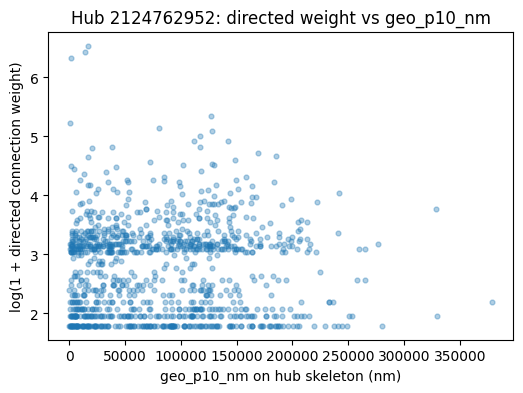

In [ ]:
plot_metric = "geo_p10_nm"

plt.figure(figsize=(6, 4))
plt.scatter(
    geo_test_df[plot_metric],
    geo_test_df["log_directed_weight"],
    alpha=0.35,
    s=12
)

plt.xlabel(f"{plot_metric} on hub skeleton (nm)")
plt.ylabel("log(1 + directed connection weight)")
plt.title(f"Hub {TEST_HUB}: directed weight vs {plot_metric}")
plt.show()

In [ ]:
def analyze_hub_geodesic(
    hub_id,
    weight_threshold=5,
    max_edges=1000,
    random_state=42,
    voxel_nm=8,
    heal_skeleton=True
):
    """
    Full geodesic analysis for one hub:

    1. Fetch synapses onto the hub.
    2. Use postsynaptic coordinates on the hub.
    3. Fetch hub skeleton.
    4. Map synapses to nearest skeleton nodes.
    5. Fetch directed connectivity among presynaptic neurons.
    6. Compute geodesic metrics for sampled directed edges.
    """
    print("\n" + "=" * 90)
    print(f"Analyzing hub geodesically: {hub_id}")
    print("=" * 90)

    t_start = time.time()

    # --------------------------
    # 1. Fetch synapses onto hub
    # --------------------------
    syn_conn = fetch_synapse_connections(None, hub_id)
    hub_syn = syn_conn[syn_conn["bodyId_post"] == hub_id].copy()

    required_cols = [
        "bodyId_pre",
        "bodyId_post",
        "x_post",
        "y_post",
        "z_post"
    ]

    missing = [c for c in required_cols if c not in hub_syn.columns]
    if len(missing) > 0:
        print(f"Missing synapse columns for hub {hub_id}: {missing}")
        return pd.DataFrame()

    hub_syn = hub_syn[required_cols].dropna().copy()

    hub_syn = hub_syn.rename(
        columns={
            "x_post": "x",
            "y_post": "y",
            "z_post": "z"
        }
    )

    hub_syn["bodyId_pre"] = hub_syn["bodyId_pre"].astype(int)
    hub_syn["bodyId_post"] = hub_syn["bodyId_post"].astype(int)

    pre_neurons = hub_syn["bodyId_pre"].astype(int).unique().tolist()

    print(f"Synapses onto hub: {len(hub_syn):,}")
    print(f"Presynaptic neurons: {len(pre_neurons):,}")

    if len(pre_neurons) < 2:
        return pd.DataFrame()

    # --------------------------
    # 2. Fetch skeleton and graph
    # --------------------------
    skel = fetch_skeleton(hub_id, heal=heal_skeleton)

    if skel is None or skel.empty:
        print(f"No skeleton found for hub {hub_id}")
        return pd.DataFrame()

    G_hub = skeleton_df_to_nx(
        skel,
        directed=False,
        with_distances=True
    )

    for u, v, data in G_hub.edges(data=True):
        data["distance_nm"] = data["distance"] * voxel_nm

    print(f"Skeleton nodes: {G_hub.number_of_nodes():,}")
    print(f"Skeleton edges: {G_hub.number_of_edges():,}")
    print(f"Connected components: {nx.number_connected_components(G_hub)}")

    # --------------------------
    # 3. Map synapses to skeleton
    # --------------------------
    skel_nodes = skel[["rowId", "x", "y", "z"]].copy().reset_index(drop=True)
    skel_tree = cKDTree(skel_nodes[["x", "y", "z"]].values)

    syn_coords = hub_syn[["x", "y", "z"]].values
    nearest_dist_raw, nearest_idx = skel_tree.query(syn_coords, k=1)

    hub_syn_mapped_local = hub_syn.copy()
    hub_syn_mapped_local["nearest_skel_rowId"] = (
        skel_nodes.iloc[nearest_idx]["rowId"].values
    )
    hub_syn_mapped_local["dist_to_skeleton_nm"] = nearest_dist_raw * voxel_nm

    print(
        "Median snap distance:",
        f"{hub_syn_mapped_local['dist_to_skeleton_nm'].median():,.1f} nm"
    )
    print(
        "95th percentile snap distance:",
        f"{hub_syn_mapped_local['dist_to_skeleton_nm'].quantile(0.95):,.1f} nm"
    )

    nodes_by_neuron_local, unique_nodes_by_neuron_local, syn_count_by_neuron_local = (
        build_synapse_node_objects(hub_syn_mapped_local)
    )

    # --------------------------
    # 4. Fetch directed connectivity among presynaptic neurons
    # --------------------------
    _, edges_raw = fetch_adjacencies(
        NC(bodyId=pre_neurons),
        NC(bodyId=pre_neurons)
    )

    directed_edges = clean_directed_edges(
        edges_raw,
        weight_threshold=weight_threshold
    )

    print(f"Directed edges with weight >= {weight_threshold}: {len(directed_edges):,}")

    if directed_edges.empty:
        return pd.DataFrame()

    directed_edges_sampled = sample_directed_edges(
        directed_edges,
        max_edges=max_edges,
        random_state=random_state
    )

    print(f"Directed edges selected: {len(directed_edges_sampled):,}")

    # --------------------------
    # 5. Compute geodesic metrics
    # --------------------------
    rows = directed_edges_sampled.to_dict("records")
    results = []

    for i, row in enumerate(rows):
        if i % 100 == 0:
            print(f"  Pair {i:,} / {len(rows):,}")

        result = compute_directed_geodesic_metrics(
            row,
            hub_id,
            G_hub,
            nodes_by_neuron_local,
            syn_count_by_neuron_local
        )

        if result is not None:
            results.append(result)

    hub_geo_df = pd.DataFrame(results)

    print(f"Valid geodesic rows: {len(hub_geo_df):,}")
    print(f"Total time for hub {hub_id}: {(time.time() - t_start):.1f} sec")

    return hub_geo_df

In [ ]:
geo_one_hub_df = analyze_hub_geodesic(
    TEST_HUB,
    weight_threshold=WEIGHT_THRESHOLD,
    max_edges=1000,
    random_state=RANDOM_STATE,
    voxel_nm=VOXEL_NM
)

display(geo_one_hub_df.head())
print(geo_one_hub_df.shape)


Analyzing hub geodesically: 2124762952


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/19584 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/22 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Directed edges with weight >= 5: 9,403
Directed edges selected: 1,000
  Pair 0 / 1,000
  Pair 100 / 1,000
  Pair 200 / 1,000
  Pair 300 / 1,000
  Pair 400 / 1,000
  Pair 500 / 1,000
  Pair 600 / 1,000
  Pair 700 / 1,000
  Pair 800 / 1,000
  Pair 900 / 1,000
Valid geodesic rows: 1,000
Total time for hub 2124762952: 430.3 sec


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
0,2124762952,1873086710,1343403608,692.0,18,268,18,268,4824,0.000000,7307.890091,16907.237709,45353.811665,104393.883575,99391.819377,144925.721840,177706.921234,0.006993,286
1,2124762952,695124651,1072063538,616.0,3,16,3,16,48,3290.440796,3290.440796,14241.476526,47072.710438,93447.376312,83833.836860,129318.946007,131244.551341,0.000000,19
2,2124762952,5813061218,1343403608,562.0,793,268,268,793,212524,0.000000,704.763214,1120.000000,3846.116089,14401.945236,21249.209252,27424.592667,54822.040131,0.013195,1061
3,2124762952,5813067929,1343403608,208.0,2,268,2,268,536,2291.927673,68764.035817,126723.651207,181238.986359,207772.181778,192919.563254,226218.015751,243090.948251,0.000000,270
4,2124762952,1128274593,5813020795,184.0,2,6,2,6,12,548.685730,548.685730,548.685730,19462.827423,41057.112457,41638.879026,64086.955513,73900.263906,0.000000,8


(1000, 19)


In [ ]:
GEO_NUM_HUBS_FIRST_PASS = 5
MAX_EDGES_PER_HUB_FIRST_PASS = 1000

geo_first_pass_results = []

for hub_id in hubs_df["bodyId"].head(GEO_NUM_HUBS_FIRST_PASS).astype(int).tolist():
    hub_geo_df = analyze_hub_geodesic(
        hub_id,
        weight_threshold=WEIGHT_THRESHOLD,
        max_edges=MAX_EDGES_PER_HUB_FIRST_PASS,
        random_state=RANDOM_STATE,
        voxel_nm=VOXEL_NM
    )

    if hub_geo_df is not None and not hub_geo_df.empty:
        geo_first_pass_results.append(hub_geo_df)

geo_scaled_df = pd.concat(geo_first_pass_results, ignore_index=True)

print("\n" + "=" * 90)
print("GEODESIC FIRST PASS DATASET")
print("=" * 90)
print(f"Rows: {len(geo_scaled_df):,}")
print(f"Hubs: {geo_scaled_df['hub'].nunique():,}")

display(geo_scaled_df.head())
display(geo_scaled_df.describe())


Analyzing hub geodesically: 2124762952


  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/19584 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

0it [00:00, ?it/s]

Directed edges with weight >= 5: 26,319
Directed edges selected: 1,000
  Pair 0 / 1,000
  Pair 100 / 1,000
  Pair 200 / 1,000
  Pair 300 / 1,000
  Pair 400 / 1,000
  Pair 500 / 1,000
  Pair 600 / 1,000
  Pair 700 / 1,000
  Pair 800 / 1,000
  Pair 900 / 1,000
Valid geodesic rows: 1,000
Total time for hub 425276848: 480.9 sec

GEODESIC FIRST PASS DATASET
Rows: 5,000
Hubs: 5


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
0,2124762952,1873086710,1343403608,692.0,18,268,18,268,4824,0.000000,7307.890091,16907.237709,45353.811665,104393.883575,99391.819377,144925.721840,177706.921234,0.006993,286
1,2124762952,695124651,1072063538,616.0,3,16,3,16,48,3290.440796,3290.440796,14241.476526,47072.710438,93447.376312,83833.836860,129318.946007,131244.551341,0.000000,19
2,2124762952,5813061218,1343403608,562.0,793,268,268,793,212524,0.000000,704.763214,1120.000000,3846.116089,14401.945236,21249.209252,27424.592667,54822.040131,0.013195,1061
3,2124762952,5813067929,1343403608,208.0,2,268,2,268,536,2291.927673,68764.035817,126723.651207,181238.986359,207772.181778,192919.563254,226218.015751,243090.948251,0.000000,270
4,2124762952,1128274593,5813020795,184.0,2,6,2,6,12,548.685730,548.685730,548.685730,19462.827423,41057.112457,41638.879026,64086.955513,73900.263906,0.000000,8


,hub,source_neuron,target_neuron,directed_weight,source_syn_count_onto_hub,target_syn_count_onto_hub,min_syn_count_onto_hub,max_syn_count_onto_hub,product_syn_count_onto_hub,geo_min_nm,geo_p05_nm,geo_p10_nm,geo_p25_nm,geo_median_nm,geo_mean_nn_nm,geo_p75_nm,geo_p90_nm,geo_zero_fraction,nn_synapse_count_total
count,5.000000e+03,5.000000e+03,5.000000e+03,5000.00000,5000.000000,5000.00000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,9.892611e+08,2.240938e+09,2.309267e+09,73.03420,79.106400,83.34960,15.750800,146.705200,1.172080e+04,56330.599313,62258.737237,69933.185606,89212.820481,118178.816956,123640.961710,153827.935168,180550.429963,0.002577,162.456000
std,7.463701e+08,2.039548e+09,2.097544e+09,130.14065,424.707446,455.14784,40.995341,614.237832,1.163352e+05,90648.779778,90247.156071,91944.614349,94970.051214,101687.013801,97934.540427,113192.921359,123722.638775,0.017248,630.708056
min,3.295662e+08,2.661876e+08,2.661873e+08,5.00000,1.000000,1.00000,1.000000,1.000000,1.000000e+00,0.000000,0.000000,0.000000,0.000000,256.000000,362.038666,362.038666,362.038666,0.000000,2.000000
25%,4.252768e+08,7.317369e+08,7.031066e+08,8.00000,3.000000,2.00000,1.000000,7.000000,1.200000e+01,2402.276993,6656.465849,11201.859230,23459.633699,45608.776374,56467.036009,74482.319386,96953.131423,0.000000,10.000000
50%,4.257903e+08,1.437303e+09,1.408207e+09,24.50000,10.000000,8.00000,3.000000,21.000000,7.200000e+01,12860.174324,22023.673762,30713.973221,56710.829735,90452.299599,96879.674970,126067.309019,148620.836966,0.000000,29.000000
75%,1.640909e+09,2.186908e+09,5.812979e+09,115.00000,40.000000,32.00000,12.000000,59.000000,4.952500e+02,78847.878527,86833.175134,100771.079234,127298.517746,160328.554965,163092.715114,197711.647367,224448.098351,0.000000,66.000000
max,2.124763e+09,7.112617e+09,7.112617e+09,4299.00000,4299.000000,4299.00000,833.000000,4299.000000,3.581067e+06,696248.011246,696248.011246,696248.011246,746527.235878,748877.339146,723320.719908,756295.006617,764082.992657,0.500000,5132.000000


In [ ]:
geo_scaled_df["log_directed_weight"] = np.log1p(geo_scaled_df["directed_weight"])

geo_metrics_to_check = [
    "geo_min_nm",
    "geo_p05_nm",
    "geo_p10_nm",
    "geo_p25_nm",
    "geo_median_nm",
    "geo_mean_nn_nm",
    "geo_zero_fraction"
]

scaled_corr_rows = []

for metric in geo_metrics_to_check:
    temp = geo_scaled_df[["log_directed_weight", metric]].dropna().copy()

    if len(temp) < 10 or temp[metric].nunique() < 2:
        continue

    spearman_rho, spearman_p = spearmanr(
        temp["log_directed_weight"],
        temp[metric]
    )

    pearson_r, pearson_p = pearsonr(
        temp["log_directed_weight"],
        temp[metric]
    )

    scaled_corr_rows.append({
        "metric": metric,
        "n": len(temp),
        "spearman_rho": spearman_rho,
        "spearman_p": spearman_p,
        "pearson_r": pearson_r,
        "pearson_p": pearson_p
    })

geo_scaled_corr_df = pd.DataFrame(scaled_corr_rows)

display(geo_scaled_corr_df.sort_values("spearman_rho"))

,metric,n,spearman_rho,spearman_p,pearson_r,pearson_p
0,geo_min_nm,5000,-0.111292,2.970966e-15,-0.026205,0.063912
1,geo_p05_nm,5000,-0.089881,1.929112e-10,-0.027147,0.054924
2,geo_p10_nm,5000,-0.076102,7.135439e-08,-0.024505,0.083166
3,geo_p25_nm,5000,-0.051158,2.958802e-04,-0.014689,0.299044
4,geo_median_nm,5000,-0.018668,1.868873e-01,0.013138,0.352993
5,geo_mean_nn_nm,5000,-0.017361,2.196698e-01,0.020648,0.144346
6,geo_zero_fraction,5000,0.046517,1.001030e-03,0.002792,0.843537


In [ ]:
per_hub_geo_corr_rows = []

for hub_id, group in geo_scaled_df.groupby("hub"):
    group = group.copy()
    group["log_directed_weight"] = np.log1p(group["directed_weight"])

    for metric in geo_metrics_to_check:
        temp = group[["log_directed_weight", metric]].dropna().copy()

        if len(temp) < 20 or temp[metric].nunique() < 2:
            continue

        spearman_rho, spearman_p = spearmanr(
            temp["log_directed_weight"],
            temp[metric]
        )

        per_hub_geo_corr_rows.append({
            "hub": int(hub_id),
            "metric": metric,
            "n": len(temp),
            "spearman_rho": spearman_rho,
            "spearman_p": spearman_p
        })

per_hub_geo_corr_df = pd.DataFrame(per_hub_geo_corr_rows)

display(
    per_hub_geo_corr_df
    .sort_values(["metric", "spearman_rho"])
    .reset_index(drop=True)
)

summary_by_metric = (
    per_hub_geo_corr_df
    .groupby("metric")["spearman_rho"]
    .agg(["count", "mean", "median", "min", "max"])
    .reset_index()
    .sort_values("median")
)

display(summary_by_metric)

,hub,metric,n,spearman_rho,spearman_p
0,1640909284,geo_mean_nn_nm,1000,-0.484990,3.992943e-60
1,329566174,geo_mean_nn_nm,1000,-0.056672,7.324174e-02
2,2124762952,geo_mean_nn_nm,1000,0.093318,3.139695e-03
3,425790257,geo_mean_nn_nm,1000,0.270975,2.734673e-18
4,425276848,geo_mean_nn_nm,1000,0.385556,8.644319e-37
5,1640909284,geo_median_nm,1000,-0.469692,5.180426e-56
6,329566174,geo_median_nm,1000,-0.080558,1.082077e-02
7,2124762952,geo_median_nm,1000,0.110463,4.661701e-04
8,425790257,geo_median_nm,1000,0.265707,1.274556e-17
9,425276848,geo_median_nm,1000,0.351762,1.689198e-30


,metric,count,mean,median,min,max
2,geo_min_nm,5,-0.100702,-0.148345,-0.368406,0.254401
3,geo_p05_nm,5,-0.060294,-0.019476,-0.405836,0.280122
4,geo_p10_nm,5,-0.037381,0.031095,-0.431732,0.281016
5,geo_p25_nm,5,-0.004690,0.063205,-0.462851,0.288228
6,geo_zero_fraction,5,0.031917,0.076537,-0.196812,0.221294
0,geo_mean_nn_nm,5,0.041637,0.093318,-0.484990,0.385556
1,geo_median_nm,5,0.035536,0.110463,-0.469692,0.351762


In [ ]:
geo_scaled_df.to_csv("geodesic_first_pass_results.csv", index=False)
geo_scaled_corr_df.to_csv("geodesic_first_pass_correlations.csv", index=False)
per_hub_geo_corr_df.to_csv("geodesic_first_pass_per_hub_correlations.csv", index=False)

print("Saved:")
print("- geodesic_first_pass_results.csv")
print("- geodesic_first_pass_correlations.csv")
print("- geodesic_first_pass_per_hub_correlations.csv")

Saved:
- geodesic_first_pass_results.csv
- geodesic_first_pass_correlations.csv
- geodesic_first_pass_per_hub_correlations.csv
